In [2]:
import pandas as pd
import numpy as np


# Configurações visuais do Pandas para não truncar colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
df = pd.read_csv('../data/archive/WA_Fn-UseC_-Accounts-Receivable.csv')

print("=== Dimensões do Dataset ===")
print(df.shape)
print("\n=== Tipos de Dados Originais ===")
print(df.dtypes)
print("\n=== Valores Nulos por Coluna ===")
print(df.isnull().sum())

# Visualização das primeiras linhas
display(df.head())

=== Dimensões do Dataset ===
(2466, 12)

=== Tipos de Dados Originais ===
countrycode        int64
customerID        object
PaperlessDate     object
invoiceNumber      int64
InvoiceDate       object
DueDate           object
InvoiceAmount    float64
Disputed          object
SettledDate       object
PaperlessBill     object
DaysToSettle       int64
DaysLate           int64
dtype: object

=== Valores Nulos por Coluna ===
countrycode      0
customerID       0
PaperlessDate    0
invoiceNumber    0
InvoiceDate      0
DueDate          0
InvoiceAmount    0
Disputed         0
SettledDate      0
PaperlessBill    0
DaysToSettle     0
DaysLate         0
dtype: int64


,countrycode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,770,3993-QUNVJ,31/12/2012,280670965,03/01/2012,02/02/2012,50.39,No,23/01/2012,Paper,20,0
1,391,6708-DPYTF,02/08/2012,5133177585,03/01/2012,02/02/2012,55.37,No,16/02/2012,Paper,44,14
2,818,1604-LIFKX,16/03/2013,5928070131,03/01/2012,02/02/2012,97.60,No,25/02/2012,Paper,53,23
3,818,8887-NCUZC,22/01/2013,6050714721,03/01/2012,02/02/2012,15.99,Yes,15/02/2012,Paper,43,13
4,406,5164-VMYWJ,27/11/2013,6393629835,03/01/2012,02/02/2012,71.33,No,30/01/2012,Paper,27,0


In [4]:
print("=== Resumo Numérico ===")
display(df.describe())

print("\n=== Resumo Categórico ===")
display(df.describe(include=['object', 'category']))

=== Resumo Numérico ===


,countrycode,invoiceNumber,InvoiceAmount,DaysToSettle,DaysLate
count,2466.000000,2.466000e+03,2466.000000,2466.00000,2466.000000
mean,620.446067,4.978431e+09,59.895856,26.44485,3.442417
std,215.933610,2.884272e+09,20.435838,12.33493,6.290607
min,391.000000,6.113650e+05,5.260000,0.00000,0.000000
25%,406.000000,2.528854e+09,46.400000,18.00000,0.000000
50%,770.000000,4.964228e+09,60.560000,26.00000,0.000000
75%,818.000000,7.494512e+09,73.765000,35.00000,5.000000
max,897.000000,9.990244e+09,128.280000,75.00000,45.000000



=== Resumo Categórico ===


,customerID,PaperlessDate,InvoiceDate,DueDate,Disputed,SettledDate,PaperlessBill
count,2466,2466,2466,2466,2466,2466,2466
unique,100,91,681,681,2,695,2
top,9149-MATVB,11/09/2012,22/08/2013,21/09/2013,No,28/05/2013,Paper
freq,36,58,10,10,1905,10,1263


In [5]:
# 1. Conversão das colunas de data para datetime
date_columns = ['PaperlessDate', 'InvoiceDate', 'DueDate', 'SettledDate']

for col in date_columns:
    # errors='coerce' transforma valores inválidos/vazios em NaT (Not a Time)
    # dayfirst=True assume formato DD/MM/YYYY (ajuste se o seu CSV for MM/DD/YYYY)
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# 2. Conversão de variáveis booleanas/binárias
# Mapeando Disputed (Yes/No) para 1/0
df['Disputed'] = df['Disputed'].map({'Yes': 1, 'No': 0})

# Mapeando PaperlessBill (Electronic/Paper) para 1/0
df['PaperlessBill'] = df['PaperlessBill'].map({'Electronic': 1, 'Paper': 0})

# 3. Criação da variável contínua de Adesão Digital
# Se PaperlessDate for NaT, o resultado da subtração será NaT. Preenchemos com 0 dias.
df['DiasDesdeAdesaoDigital'] = (df['InvoiceDate'] - df['PaperlessDate']).dt.days
df['DiasDesdeAdesaoDigital'] = df['DiasDesdeAdesaoDigital'].fillna(0).clip(lower=0) # clip evita dias negativos se houver erro no ERP

# Removemos a data original pois o modelo não lê timestamp
df = df.drop(columns=['PaperlessDate'])

print("=== Tipos de Dados Após Tratamento ===")
print(df.dtypes)

=== Tipos de Dados Após Tratamento ===
countrycode                        int64
customerID                        object
invoiceNumber                      int64
InvoiceDate               datetime64[ns]
DueDate                   datetime64[ns]
InvoiceAmount                    float64
Disputed                           int64
SettledDate               datetime64[ns]
PaperlessBill                      int64
DaysToSettle                       int64
DaysLate                           int64
DiasDesdeAdesaoDigital             int64
dtype: object


In [6]:
# Ordenar por Cliente e Data de Emissão da Fatura
# Isso garante que ao usarmos funções de janela (shift, rolling), 
# estaremos sempre olhando para o passado do cliente.
df = df.sort_values(by=['customerID', 'InvoiceDate']).reset_index(drop=True)

# Verificação de sanidade da ordenação
display(df[['customerID', 'InvoiceDate', 'DueDate', 'SettledDate']].head(10))

,customerID,InvoiceDate,DueDate,SettledDate
0,0187-ERLSR,2012-03-29,2012-04-28,2012-04-25
1,0187-ERLSR,2012-05-15,2012-06-14,2012-05-28
2,0187-ERLSR,2012-05-21,2012-06-20,2012-06-04
3,0187-ERLSR,2012-06-16,2012-07-16,2012-07-04
4,0187-ERLSR,2012-09-05,2012-10-05,2012-09-14
5,0187-ERLSR,2012-09-22,2012-10-22,2012-10-11
6,0187-ERLSR,2012-12-06,2013-01-05,2012-12-19
7,0187-ERLSR,2013-02-16,2013-03-18,2013-03-02
8,0187-ERLSR,2013-03-04,2013-04-03,2013-03-11
9,0187-ERLSR,2013-03-16,2013-04-15,2013-04-04


In [7]:
import duckdb

In [22]:
query2 = """
WITH base AS (
    SELECT 
        *,
        ROW_NUMBER() OVER() as row_id 
    FROM df
),

-- CTE 1: Isola o cálculo do Comportamento Fechado
comportamento_fechado AS (
    SELECT 
        t1.row_id,
        COUNT(t2.invoiceNumber) AS hist_qtd_faturas_pagas,
        
        -- Média ponderada pelo valor da fatura com proteção contra divisão por zero
        COALESCE(
            SUM(t2.DaysLate * t2.InvoiceAmount) / NULLIF(SUM(t2.InvoiceAmount), 0), 
            0
        ) AS hist_media_atraso_ponderada,
        
        COALESCE(SUM(t2.Disputed), 0) AS hist_qtd_disputas
    FROM base t1
    LEFT JOIN base t2 
        ON t1.customerID = t2.customerID 
        AND t2.SettledDate < t1.InvoiceDate
    GROUP BY t1.row_id
),

-- CTE 2: Isola o cálculo da Exposição Aberta
exposicao_aberta AS (
    SELECT 
        t1.row_id,
        COALESCE(SUM(t3.InvoiceAmount), 0) AS hist_valor_em_aberto_simultaneo
    FROM base t1
    LEFT JOIN base t3
        ON t1.customerID = t3.customerID
        AND t3.InvoiceDate < t1.InvoiceDate
        AND (t3.SettledDate >= t1.InvoiceDate OR t3.SettledDate IS NULL)
    GROUP BY t1.row_id
)

-- Join final 1-para-1 usando a chave primária temporária
SELECT 
    b.*,
    c.hist_qtd_faturas_pagas,
    c.hist_media_atraso_ponderada,
    c.hist_qtd_disputas,
    e.hist_valor_em_aberto_simultaneo
FROM base b
LEFT JOIN comportamento_fechado c ON b.row_id = c.row_id
LEFT JOIN exposicao_aberta e ON b.row_id = e.row_id
ORDER BY b.customerID, b.InvoiceDate
"""

query = """
WITH base AS (
    SELECT 
        *,
        ROW_NUMBER() OVER() as row_id,
        
        -- 1. Quantidade de faturas no histórico (0 = primeira compra)
        ROW_NUMBER() OVER(PARTITION BY customerID ORDER BY InvoiceDate) - 1 AS qtd_faturas_historico,
        
        -- 2. Dias desde a primeira compra (Tenure) - SINTAXE DUCKDB
        DATE_DIFF('day', CAST(MIN(InvoiceDate) OVER(PARTITION BY customerID) AS DATE), CAST(InvoiceDate AS DATE)) AS dias_desde_primeira_compra
        
    FROM df
),
comportamento_fechado AS (
    SELECT 
        t1.row_id,
        COUNT(t2.invoiceNumber) AS hist_qtd_faturas_pagas,
        
        COALESCE(
            SUM(t2.DaysLate * t2.InvoiceAmount) / NULLIF(SUM(t2.InvoiceAmount), 0), 
            0
        ) AS hist_media_atraso_ponderada,
        
        COALESCE(SUM(t2.Disputed), 0) AS hist_qtd_disputas,

        -- 3. Já pagou com atraso no passado? (1 = Sim, 0 = Não)
        COALESCE(MAX(CASE WHEN t2.DaysLate > 0 THEN 1 ELSE 0 END), 0) AS ja_pagou_com_atraso,

        -- 4. Frequência de atraso histórica
        COALESCE(
            CAST(SUM(CASE WHEN t2.DaysLate > 0 THEN 1 ELSE 0 END) AS FLOAT) / NULLIF(COUNT(t2.invoiceNumber), 0),
            0.0
        ) AS frequencia_atraso

    FROM base t1
    LEFT JOIN base t2 
        ON t1.customerID = t2.customerID 
        AND t2.SettledDate < t1.InvoiceDate
    GROUP BY t1.row_id
),
exposicao_aberta AS (
    SELECT 
        t1.row_id,
        COALESCE(SUM(t3.InvoiceAmount), 0) AS hist_valor_em_aberto_simultaneo
    FROM base t1
    LEFT JOIN base t3
        ON t1.customerID = t3.customerID
        AND t3.InvoiceDate < t1.InvoiceDate
        AND (t3.SettledDate >= t1.InvoiceDate OR t3.SettledDate IS NULL)
    GROUP BY t1.row_id
)
SELECT 
    b.*,
    COALESCE(c.hist_qtd_faturas_pagas, 0) AS hist_qtd_faturas_pagas,
    COALESCE(c.hist_media_atraso_ponderada, 0) AS hist_media_atraso_ponderada,
    COALESCE(c.hist_qtd_disputas, 0) AS hist_qtd_disputas,
    COALESCE(c.ja_pagou_com_atraso, 0) AS ja_pagou_com_atraso,
    COALESCE(c.frequencia_atraso, 0) AS frequencia_atraso,
    COALESCE(e.hist_valor_em_aberto_simultaneo, 0) AS hist_valor_em_aberto_simultaneo
FROM base b
LEFT JOIN comportamento_fechado c ON b.row_id = c.row_id
LEFT JOIN exposicao_aberta e ON b.row_id = e.row_id
ORDER BY b.customerID, b.InvoiceDate
"""

df_features = duckdb.query(query).df().drop(columns=['row_id'])

print("=== Novas Features Criadas ===")
display(df_features.head(5))

=== Novas Features Criadas ===


,countrycode,customerID,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,DiasDesdeAdesaoDigital,qtd_faturas_historico,dias_desde_primeira_compra,hist_qtd_faturas_pagas,hist_media_atraso_ponderada,hist_qtd_disputas,ja_pagou_com_atraso,frequencia_atraso,hist_valor_em_aberto_simultaneo
0,391,0187-ERLSR,4037644863,2012-03-29,2012-04-28,62.68,1,2012-04-25,0,27,0,0,0,0,0,0.00,0.00,0,0.00,0.00
1,391,0187-ERLSR,9471530987,2012-05-15,2012-06-14,77.19,0,2012-05-28,0,13,0,0,1,47,1,0.00,1.00,0,0.00,0.00
2,391,0187-ERLSR,9744145268,2012-05-21,2012-06-20,51.65,0,2012-06-04,0,14,0,0,2,53,1,0.00,1.00,0,0.00,77.19
3,391,0187-ERLSR,7214076449,2012-06-16,2012-07-16,64.47,1,2012-07-04,0,18,0,0,3,79,3,0.00,1.00,0,0.00,0.00
4,391,0187-ERLSR,1756742390,2012-09-05,2012-10-05,84.57,0,2012-09-14,0,9,0,0,4,160,4,0.00,2.00,0,0.00,0.00


In [10]:
# 1. Feature Engineering: Calendário e Sazonalidade
df_features['mes_vencimento'] = df_features['DueDate'].dt.month
df_features['vencimento_fim_mes'] = (df_features['DueDate'].dt.day >= 28).astype(int)
df_features['vencimento_fim_semana'] = (df_features['DueDate'].dt.dayofweek >= 5).astype(int)

# 2. Tipagem de Variáveis Categóricas
df_features['countrycode'] = df_features['countrycode'].astype('category')
df_features['mes_vencimento'] = df_features['mes_vencimento'].astype('category')

# 3. Definição do Target para o Estágio 1 (Classificação)
df_features['target_atraso'] = (df_features['DaysLate'] > 0).astype(int)

# 4. Particionamento Temporal (80/20 Estrito)
# Ordena cronologicamente para garantir que o passado fique no topo e o futuro no final
df_features = df_features.sort_values('InvoiceDate').reset_index(drop=True)

# Calcula o índice de corte (80% da base)
indice_corte = int(len(df_features) * 0.8)

# Separação
df_train = df_features.iloc[:indice_corte].copy()
df_test = df_features.iloc[indice_corte:].copy()

print(f"Total: {len(df_features)} faturas")
print(f"Treino: {len(df_train)} faturas (até {df_train['InvoiceDate'].max().date()})")
print(f"Teste: {len(df_test)} faturas (de {df_test['InvoiceDate'].min().date()} até {df_test['InvoiceDate'].max().date()})")

# 5. Isolamento de Chaves e Remoção de Vazamento de Dados
chaves = ['customerID', 'invoiceNumber', 'InvoiceDate', 'DueDate']
df_train = df_train.set_index(chaves)
df_test = df_test.set_index(chaves)

# Lista atualizada com todos os vazamentos identificados
colunas_vazamento = ['SettledDate', 'DaysLate', 'target_atraso', 'DaysToSettle'] 

X_train = df_train.drop(columns=colunas_vazamento, errors='ignore')
X_test = df_test.drop(columns=colunas_vazamento, errors='ignore')

print("\nMatriz X_train pronta para modelagem. Shape:", X_train.shape)

Total: 2466 faturas
Treino: 1972 faturas (até 2013-07-12)
Teste: 494 faturas (de 2013-07-12 até 2013-12-02)

Matriz X_train pronta para modelagem. Shape: (1972, 16)


In [17]:
from xgboost import XGBClassifier, XGBRegressor

# 1. Preparação dos Targets
y_train_class = df_train['target_atraso']
y_test_class = df_test['target_atraso']

# Filtro para o Estágio 2 (Treinar regressão APENAS com quem realmente atrasou)
mask_atraso_train = df_train['DaysLate'] > 0
X_train_reg = X_train.loc[mask_atraso_train]
y_train_reg = df_train.loc[mask_atraso_train, 'DaysLate']

# 2. Treinamento - Estágio 1 (Classificador: Vai atrasar?)
clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    enable_categorical=True
)
clf.fit(X_train, y_train_class)

# 3. Treinamento - Estágio 2 (Regressor: Quantos dias?)
reg_old = XGBRegressor(
    n_estimators=50,        # Reduz pela metade a quantidade de árvores
    max_depth=3,            # Árvores rasas (o padrão é 6, que decora dados)
    learning_rate=0.05,     # Passos menores
    min_child_weight=5,     # Impede que a árvore crie regras para 1 ou 2 faturas isoladas
    random_state=42,
    enable_categorical=True
)

reg = XGBRegressor(
    n_estimators=100,       # Aumentamos para dar tempo do modelo convergir
    max_depth=4,            # Aumentamos de 3 para 5. Agora ele pode cruzar "frequencia_atraso" com "valor_fatura"
    learning_rate=0.05,     # Mantemos o passo conservador para não errar o alvo
    min_child_weight=4,     # Reduzimos de 5 para 3. Permite isolar perfis um pouco mais específicos
    random_state=42,
    enable_categorical=True
)
reg.fit(X_train_reg, y_train_reg)

prob_atraso = clf.predict_proba(X_test)[:, 1]

# Define o corte conservador: 35% de chance já classifica como atraso
pred_class = (prob_atraso >= 0.35).astype(int)

# Previsão de dias pelo regressor
pred_dias = reg.predict(X_test)
pred_dias = np.clip(np.round(pred_dias), a_min=1, a_max=None)

# 5. Combinação Matemática (O motor do fluxo de caixa)
# Multiplica a classe ajustada pelos dias.
dias_atraso_finais = pred_class * pred_dias

print("Modelos treinados e inferência combinada concluída.")

Modelos treinados e inferência combinada concluída.


In [18]:
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error

# 1. Avaliação do Classificador (Estágio 1)
print("=== ESTÁGIO 1: CLASSIFICADOR (Vai atrasar ou não?) ===")
print("Base de Teste:")
print(classification_report(y_test_class, pred_class))

# 2. Avaliação do Regressor (Estágio 2) - Foco no Overfitting
# Precisamos prever o treino para comparar com o teste
pred_reg_train = reg.predict(X_train_reg)
pred_reg_train = np.clip(np.round(pred_reg_train), a_min=1, a_max=None)

# Isolar apenas quem realmente atrasou no Teste para avaliar o regressor de forma justa
mask_atraso_test = df_test['DaysLate'] > 0
X_test_reg = X_test.loc[mask_atraso_test]
y_test_reg = df_test.loc[mask_atraso_test, 'DaysLate']

pred_reg_test = reg.predict(X_test_reg)
pred_reg_test = np.clip(np.round(pred_reg_test), a_min=1, a_max=None)

print("\n=== ESTÁGIO 2: REGRESSOR (Quantos dias de atraso?) ===")
print(f"MAE Treino:  {mean_absolute_error(y_train_reg, pred_reg_train):.2f} dias")
print(f"MAE Teste:   {mean_absolute_error(y_test_reg, pred_reg_test):.2f} dias")
print(f"RMSE Treino: {np.sqrt(mean_squared_error(y_train_reg, pred_reg_train)):.2f} dias")
print(f"RMSE Teste:  {np.sqrt(mean_squared_error(y_test_reg, pred_reg_test)):.2f} dias")

=== ESTÁGIO 1: CLASSIFICADOR (Vai atrasar ou não?) ===
Base de Teste:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       354
           1       0.69      0.84      0.76       140

    accuracy                           0.85       494
   macro avg       0.81      0.84      0.82       494
weighted avg       0.86      0.85      0.85       494


=== ESTÁGIO 2: REGRESSOR (Quantos dias de atraso?) ===
MAE Treino:  3.47 dias
MAE Teste:   4.11 dias
RMSE Treino: 4.43 dias
RMSE Teste:  5.29 dias


In [16]:
# 1. Acoplar as previsões no dataframe original de teste
df_resultado = df_test.reset_index().copy()
df_resultado['Dias_Atraso_Previstos'] = dias_atraso_finais

# 2. Calcular a data real projetada
# Se Dias_Atraso_Previstos = 0, a data projetada é igual ao DueDate
df_resultado['Data_Pagamento_Projetada'] = df_resultado['DueDate'] + pd.to_timedelta(df_resultado['Dias_Atraso_Previstos'], unit='D')

# 3. Comparativo Financeiro: Fluxo de Caixa Ingênuo vs Ajustado por IA
fluxo_ingenuo = df_resultado.groupby('DueDate')['InvoiceAmount'].sum().reset_index()
fluxo_ingenuo.columns = ['Data', 'Receita_Esperada_Ingenua']

fluxo_ajustado = df_resultado.groupby('Data_Pagamento_Projetada')['InvoiceAmount'].sum().reset_index()
fluxo_ajustado.columns = ['Data', 'Receita_Projetada_IA']

# Junta os dois fluxos para visualização
df_fluxo_caixa = pd.merge(fluxo_ingenuo, fluxo_ajustado, on='Data', how='outer').fillna(0)
df_fluxo_caixa = df_fluxo_caixa.sort_values('Data').reset_index(drop=True)

# Criação das colunas de soma acumulada
df_fluxo_caixa['Acumulado_Ingenuo'] = df_fluxo_caixa['Receita_Esperada_Ingenua'].cumsum()
df_fluxo_caixa['Acumulado_IA'] = df_fluxo_caixa['Receita_Projetada_IA'].cumsum()

# Opcional: Criar uma coluna com a diferença (o "furo" no caixa naquele dia)
df_fluxo_caixa['Furo_de_Caixa_Acumulado'] = df_fluxo_caixa['Acumulado_Ingenuo'] - df_fluxo_caixa['Acumulado_IA']

pd.set_option('display.float_format', '{:,.2f}'.format)

print(df_fluxo_caixa.tail(50))

          Data  Receita_Esperada_Ingenua  Receita_Projetada_IA  Acumulado_Ingenuo  Acumulado_IA  Furo_de_Caixa_Acumulado
99  2013-11-20                    311.59                275.31          20,999.30     20,683.68                   315.62
100 2013-11-21                    202.55                292.86          21,201.85     20,976.54                   225.31
101 2013-11-22                    183.53                 61.19          21,385.38     21,037.73                   347.65
102 2013-11-23                    296.89                134.47          21,682.27     21,172.20                   510.07
103 2013-11-24                    163.80                243.41          21,846.07     21,415.61                   430.46
104 2013-11-25                     82.34                 82.34          21,928.41     21,497.95                   430.46
105 2013-11-26                    108.38                108.38          22,036.79     21,606.33                   430.46
106 2013-11-27                  

In [77]:
df_resultado

,customerID,invoiceNumber,InvoiceDate,DueDate,countrycode,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,DiasDesdeAdesaoDigital,hist_qtd_faturas_pagas,hist_media_atraso_ponderada,hist_qtd_disputas,hist_valor_em_aberto_simultaneo,mes_vencimento,vencimento_fim_mes,vencimento_fim_semana,target_atraso,Dias_Atraso_Previstos,Data_Pagamento_Projetada
0,9181-HEKGV,9520565243,2013-07-12,2013-08-11,818,52.48,0,2013-08-20,0,39,9,0,15,11.800016,7.0,249.80,8,0,1,1,8.0,2013-08-19
1,9322-YCTQO,1281718631,2013-07-12,2013-08-11,406,92.35,0,2013-08-12,1,31,1,462,13,7.273812,0.0,0.00,8,0,1,1,7.0,2013-08-18
2,9758-AIEIK,8161191244,2013-07-13,2013-08-12,406,109.79,1,2013-08-16,1,34,4,446,15,1.605148,3.0,112.79,8,0,0,1,9.0,2013-08-21
3,9323-NDIOV,3556859305,2013-07-13,2013-08-12,770,44.48,0,2013-08-07,1,25,0,369,15,7.618180,3.0,0.00,8,0,0,0,6.0,2013-08-18
4,9149-MATVB,1591349086,2013-07-13,2013-08-12,770,51.13,0,2013-08-07,1,25,0,74,22,0.932988,0.0,36.26,8,0,0,0,0.0,2013-08-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,7209-MDWKR,2189582262,2013-12-02,2014-01-01,391,67.69,0,2013-12-28,1,26,0,54,22,3.950117,0.0,80.14,1,0,0,0,0.0,2014-01-01
490,8887-NCUZC,2455126326,2013-12-02,2014-01-01,818,49.51,0,2014-01-07,1,36,6,314,34,5.795900,13.0,0.00,1,0,0,1,0.0,2014-01-01
491,6391-GBFQJ,9366628825,2013-12-02,2014-01-01,897,18.05,0,2013-12-13,1,11,0,7,16,0.185283,3.0,34.22,1,0,0,0,0.0,2014-01-01
492,6391-GBFQJ,9835528694,2013-12-02,2014-01-01,897,8.38,1,2013-12-30,1,28,0,7,16,0.185283,3.0,34.22,1,0,0,0,0.0,2014-01-01


In [78]:
fluxo_ajustado

,Data,Receita_Projetada_IA
0,2013-08-12,132.76
1,2013-08-14,74.96
2,2013-08-16,76.26
3,2013-08-18,248.40
4,2013-08-19,157.31
...,...,...
138,2014-01-03,70.45
139,2014-01-04,25.19
140,2014-01-05,247.29
141,2014-01-06,159.89


In [25]:
# 1. Acoplar todas as previsões no dataframe original de teste
df_resultado = df_test.reset_index().copy()

# O que o classificador achou (0 = no prazo, 1 = atraso)
df_resultado['Pred_Classificador'] = pred_class

# Quantos dias o regressor calculou (sempre >= 1)
df_resultado['Pred_Regressor_Dias'] = pred_dias

# O resultado da multiplicação (o que realmente vai para o fluxo de caixa)
df_resultado['Dias_Atraso_Finais'] = dias_atraso_finais

# 2. Calcular a data real projetada
df_resultado['Data_Pagamento_Projetada'] = df_resultado['DueDate'] + pd.to_timedelta(df_resultado['Dias_Atraso_Finais'], unit='D')

In [26]:
# Exporta o resumo financeiro (o fluxo de caixa agrupado por dia)
df_fluxo_caixa.to_csv('../data/projecao_fluxo_caixa.csv', index=False)

# Exporta a base detalhada (fatura a fatura com a previsão de atraso de cada uma)
df_resultado.to_csv('../data/previsoes_detalhadas_teste.csv', index=False)

print("Arquivos CSV exportados com sucesso!")

Arquivos CSV exportados com sucesso!


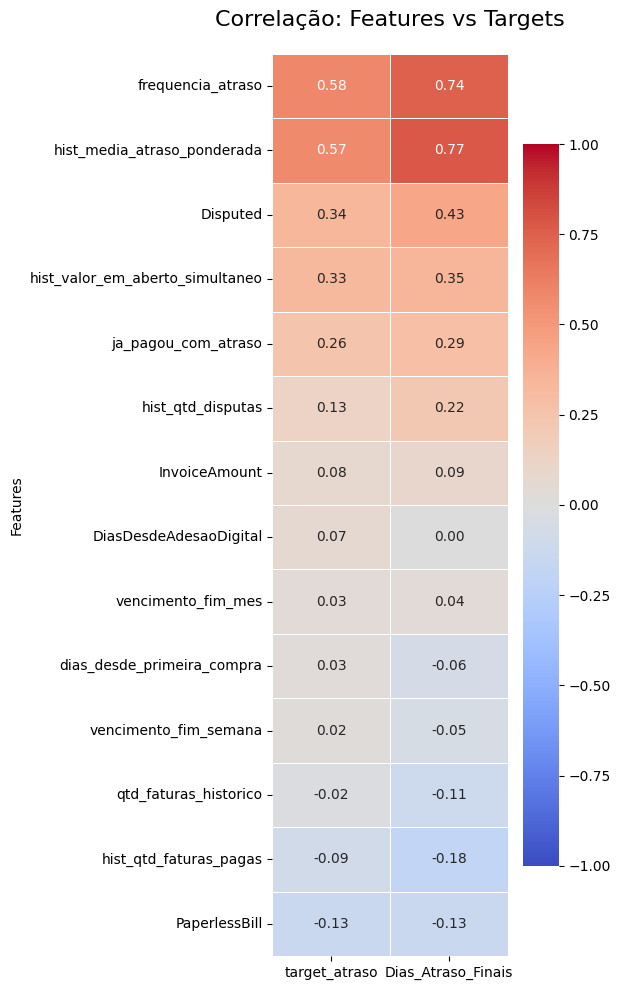

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garante que a target_atraso existe e é numérica (0 e 1)
df_resultado['target_atraso'] = (df_resultado['DaysLate'] > 0).astype(int)

# 2. Definir colunas para ignorar (IDs, Datas e Vazamento de Dados)
colunas_para_ignorar = [
    'customerID', 'invoiceNumber', 'countrycode', # IDs e categorias puras
    'InvoiceDate', 'DueDate', 'SettledDate',      # Datas
    'DaysToSettle', 'DaysLate'  , 'Pred_Classificador' , 'Pred_Regressor_Dias'                 # VAZAMENTO DE DADOS
]

# Filtra o dataframe removendo as colunas indesejadas
df_corr = df_resultado.drop(columns=[col for col in colunas_para_ignorar if col in df_resultado.columns])

# Garante que apenas variáveis numéricas entrem na correlação
df_corr = df_corr.select_dtypes(include=[np.number])

# 3. Calcular a matriz de correlação (Pearson)
matriz_correlacao = df_corr.corr()

# 4. Filtrar a matriz para mostrar apenas as colunas alvo
# Se o nome da sua coluna de dias for diferente, altere aqui:
alvos = ['target_atraso', 'Dias_Atraso_Finais'] 

# Garante que não vai dar erro se o nome da coluna estiver diferente
alvos_presentes = [col for col in alvos if col in matriz_correlacao.columns]

# Mantém apenas as colunas alvo e remove as linhas alvo (para não comparar target com target)
corr_filtrada = matriz_correlacao[alvos_presentes].drop(index=alvos_presentes, errors='ignore')

# Ordena da maior para a menor correlação em relação ao target_atraso (facilita a leitura)
corr_filtrada = corr_filtrada.sort_values(by=alvos_presentes[0], ascending=False)

# 5. Plotar o Heatmap
plt.figure(figsize=(6, 10)) # Gráfico mais estreito, pois tem apenas 2 colunas

# Plota o mapa de calor SEM a máscara (mask), pois agora é um retângulo, não um quadrado
sns.heatmap(
    corr_filtrada, 
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    vmin=-1, vmax=1,     
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Correlação: Features vs Targets', fontsize=16, pad=20)
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [20]:
df.columns

Index(['countrycode', 'customerID', 'invoiceNumber', 'InvoiceDate', 'DueDate', 'InvoiceAmount', 'Disputed', 'SettledDate', 'PaperlessBill', 'DaysToSettle', 'DaysLate', 'DiasDesdeAdesaoDigital'], dtype='object')